# Step 1. Introduction & ML Objective

## Machine Learning Objective

The objective of this stage is to build a machine learning model that can forecast daily sales for Rossmann stores using historical sales patterns, promotions, holidays, store characteristics, competition, and date-based features.

Since the test dataset represents a future time period, the model will be trained using historical data and evaluated using a chronological validation approach to better reflect the real forecasting scenario.

## Target Variable

The target variable is Sales, which represents the daily sales generated by a store.

Customers was used during EDA to understand purchasing behaviour and its relationship with sales. However, it is excluded from the predictive feature set because customer counts are not available in the test dataset. Including it would make the model dependent on information that would not be available at forecasting time.

## Forecasting Approach

The machine learning workflow will include data preparation, feature engineering, preprocessing, regression model development, evaluation, hyperparameter tuning, feature importance analysis, prediction uncertainty estimation, and model serialization.

The primary regression model will be Random Forest Regressor, along with a baseline and additional regression models where useful.

# Step 2. Import Required Libraries

In [7]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Logging
import logging

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    force=True
)

logger = logging.getLogger(__name__)

logger.info("Libraries imported and logging configured successfully.")

2026-09-12 05:48:48,878 - INFO - Libraries imported and logging configured successfully.


# Step 3. Load & Prepare Data

## Load Train, Test and Store Data

In [ ]:
# Load datasets

train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")
store_df = pd.read_csv("../data/store.csv")

logger.info("Train, test, and store datasets loaded successfully.")

print("Train Dataset Shape:", train_df.shape)
print("Test Dataset Shape:", test_df.shape)
print("Store Dataset Shape:", store_df.shape)

/tmp/ipykernel_36882/1790086155.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("train.csv")
2026-09-12 05:48:53,916 - INFO - Train, test, and store datasets loaded successfully.


Train Dataset Shape: (1017209, 9)
Test Dataset Shape: (41088, 8)
Store Dataset Shape: (1115, 10)


## Merge Train and Test Data with Store Data
Store-level characteristics are required as model features, so we merge store.csv with both train and test datasets using the Store identifier.

In [9]:
# Merge store information with train and test data

train_model = train_df.merge(
    store_df,
    on="Store",
    how="left"
)

test_model = test_df.merge(
    store_df,
    on="Store",
    how="left"
)

logger.info("Store information merged successfully with train and test data.")

print("Train Modeling Dataset Shape:", train_model.shape)
print("Test Modeling Dataset Shape:", test_model.shape)

2026-09-12 05:48:55,281 - INFO - Store information merged successfully with train and test data.


Train Modeling Dataset Shape: (1017209, 18)
Test Modeling Dataset Shape: (41088, 17)


Observation
* Store information has been successfully added to both datasets.
* The train and test datasets remain separate, preserving the future forecasting setup.

## Analyze Missing Values
The EDA identified missing values in several columns. Before model training, we analyze their patterns to determine whether they represent genuine missing information or cases where a feature is not applicable.

In [10]:
# Check missing values before handling

print("Train Missing Values:")
display(train_model.isnull().sum()[train_model.isnull().sum() > 0])

print("Test Missing Values:")
display(test_model.isnull().sum()[test_model.isnull().sum() > 0])

Train Missing Values:


,0
CompetitionDistance,2642
CompetitionOpenSinceMonth,323348
CompetitionOpenSinceYear,323348
Promo2SinceWeek,508031
Promo2SinceYear,508031
PromoInterval,508031


Test Missing Values:


,0
Open,11
CompetitionDistance,96
CompetitionOpenSinceMonth,15216
CompetitionOpenSinceYear,15216
Promo2SinceWeek,17232
Promo2SinceYear,17232
PromoInterval,17232


### Inspect Missing-Value Patterns

In [11]:
# Inspect missing-value patterns

missing_cols = [
    "Open",
    "CompetitionDistance",
    "CompetitionOpenSinceMonth",
    "CompetitionOpenSinceYear",
    "Promo2SinceWeek",
    "Promo2SinceYear",
    "PromoInterval"
]

for col in missing_cols:
    print(f"\n{col}")
    print("Train missing rows:", train_model[col].isnull().sum())
    print("Test missing rows:", test_model[col].isnull().sum())


Open
Train missing rows: 0
Test missing rows: 11

CompetitionDistance
Train missing rows: 2642
Test missing rows: 96

CompetitionOpenSinceMonth
Train missing rows: 323348
Test missing rows: 15216

CompetitionOpenSinceYear
Train missing rows: 323348
Test missing rows: 15216

Promo2SinceWeek
Train missing rows: 508031
Test missing rows: 17232

Promo2SinceYear
Train missing rows: 508031
Test missing rows: 17232

PromoInterval
Train missing rows: 508031
Test missing rows: 17232


In [12]:
# Check Promo2 status for missing Promo2-related information

print("Promo2 distribution where Promo2SinceWeek is missing:")
display(
    train_model.loc[
        train_model["Promo2SinceWeek"].isnull(),
        "Promo2"
    ].value_counts(dropna=False)
)

print("\nPromo2 distribution where PromoInterval is missing:")
display(
    train_model.loc[
        train_model["PromoInterval"].isnull(),
        "Promo2"
    ].value_counts(dropna=False)
)

Promo2 distribution where Promo2SinceWeek is missing:


,count
Promo2,
0,508031



Promo2 distribution where PromoInterval is missing:


,count
Promo2,
0,508031


Observation
* The missing values in Promo2SinceWeek, Promo2SinceYear, and PromoInterval occur only for stores where Promo2 = 0.
* This indicates that these fields are not applicable when the store is not participating in Promo2.
* Therefore, these columns will be handled based on their business meaning during feature engineering rather than using generic imputation.

### Analyze Competition Information
Competition-related attributes provide information about competitor proximity and, where available, the month and year when the competitor became established.

In [13]:
# Analyze competition-related missing values at store level

competition_check = store_df[
    [
        "Store",
        "CompetitionDistance",
        "CompetitionOpenSinceMonth",
        "CompetitionOpenSinceYear"
    ]
].copy()

print("Stores with missing CompetitionDistance:")
display(
    competition_check[
        competition_check["CompetitionDistance"].isnull()
    ]
)

print("\nStores with missing CompetitionOpenSinceMonth/Year:")
display(
    competition_check[
        competition_check["CompetitionOpenSinceMonth"].isnull() &
        competition_check["CompetitionOpenSinceYear"].isnull()
    ].head(20)
)

Stores with missing CompetitionDistance:


,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear
290,291,NaN,NaN,NaN
621,622,NaN,NaN,NaN
878,879,NaN,NaN,NaN



Stores with missing CompetitionOpenSinceMonth/Year:


,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear
11,12,1070.0,NaN,NaN
12,13,310.0,NaN,NaN
15,16,3270.0,NaN,NaN
18,19,3240.0,NaN,NaN
21,22,1040.0,NaN,NaN
25,26,2300.0,NaN,NaN
28,29,2170.0,NaN,NaN
31,32,2910.0,NaN,NaN
39,40,180.0,NaN,NaN
40,41,1180.0,NaN,NaN


Observation

* CompetitionDistance is missing for only three stores, while CompetitionOpenSinceMonth and CompetitionOpenSinceYear are missing for several stores.
* The stores with missing competition opening information can still have a valid CompetitionDistance, indicating that missing opening dates do not necessarily mean that competition is absent.
* Therefore, CompetitionDistance and competition opening information will be handled separately during missing-value treatment.

## Handle Missing Values

### Handle Promo2-Related Missing Values
The missing values in Promo2SinceWeek, Promo2SinceYear, and PromoInterval are associated with stores where Promo2 is not active. Since these fields are not applicable to such stores, they are replaced with 0 for the numeric fields and "None" for the categorical field.

In [14]:
# Handle Promo2-related missing values

train_model["Promo2SinceWeek"] = train_model["Promo2SinceWeek"].fillna(0)
test_model["Promo2SinceWeek"] = test_model["Promo2SinceWeek"].fillna(0)

train_model["Promo2SinceYear"] = train_model["Promo2SinceYear"].fillna(0)
test_model["Promo2SinceYear"] = test_model["Promo2SinceYear"].fillna(0)

train_model["PromoInterval"] = train_model["PromoInterval"].fillna("None")
test_model["PromoInterval"] = test_model["PromoInterval"].fillna("None")

logger.info("Promo2-related missing values handled successfully.")

2026-09-12 05:49:09,155 - INFO - Promo2-related missing values handled successfully.


Observation

Promo2-related missing values have been handled using meaningful placeholder values. 0 represents that the corresponding numeric Promo2 information is not applicable, while "None" represents the absence of a Promo2 interval.

### Handle Competition-Related Missing Values
Competition information consists of competitor distance and competitor opening date information. Since these fields have different meanings, they are handled separately. Missing competition distance indicates that competitor distance is unavailable, while missing opening month and year indicate that the competitor opening information is unavailable.

In [15]:
# Handle CompetitionDistance using median imputation

competition_distance_median = train_model["CompetitionDistance"].median()

train_model["CompetitionDistance"] = train_model["CompetitionDistance"].fillna(
    competition_distance_median
)

test_model["CompetitionDistance"] = test_model["CompetitionDistance"].fillna(
    competition_distance_median
)


# Handle missing competition opening information

train_model["CompetitionOpenSinceMonth"] = train_model[
    "CompetitionOpenSinceMonth"
].fillna(0)

test_model["CompetitionOpenSinceMonth"] = test_model[
    "CompetitionOpenSinceMonth"
].fillna(0)

train_model["CompetitionOpenSinceYear"] = train_model[
    "CompetitionOpenSinceYear"
].fillna(0)

test_model["CompetitionOpenSinceYear"] = test_model[
    "CompetitionOpenSinceYear"
].fillna(0)

logger.info("Competition-related missing values handled successfully.")

2026-09-12 05:49:10,956 - INFO - Competition-related missing values handled successfully.


### Handle Missing Open Values
The Open column indicates whether a store was open on a particular day. The training data does not contain missing values for this field, while a small number of records in the test data have missing Open values. Since these records belong to the future prediction period, the missing values need to be handled before generating predictions.

In [16]:
# Inspect test records with missing Open values

missing_open_test = test_model[
    test_model["Open"].isnull()
][
    ["Store", "DayOfWeek", "Date", "Promo", "StateHoliday", "SchoolHoliday"]
]

display(missing_open_test)

,Store,DayOfWeek,Date,Promo,StateHoliday,SchoolHoliday
479,622,4,2015-09-17,1,0,0
1335,622,3,2015-09-16,1,0,0
2191,622,2,2015-09-15,1,0,0
3047,622,1,2015-09-14,1,0,0
4759,622,6,2015-09-12,0,0,0
5615,622,5,2015-09-11,0,0,0
6471,622,4,2015-09-10,0,0,0
7327,622,3,2015-09-09,0,0,0
8183,622,2,2015-09-08,0,0,0
9039,622,1,2015-09-07,0,0,0


In [17]:
# Check historical Open behaviour for Store 622

store_622_history = train_model[
    train_model["Store"] == 622
][
    ["Store", "DayOfWeek", "Date", "Open", "Promo", "StateHoliday", "SchoolHoliday"]
].sort_values("Date")

display(store_622_history.tail(20))

,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
21806,622,7,2015-07-12,0,0,0,0
20691,622,1,2015-07-13,1,1,0,0
19576,622,2,2015-07-14,1,1,0,0
18461,622,3,2015-07-15,1,1,0,0
17346,622,4,2015-07-16,1,1,0,0
16231,622,5,2015-07-17,1,1,0,0
15116,622,6,2015-07-18,1,0,0,0
14001,622,7,2015-07-19,0,0,0,0
12886,622,1,2015-07-20,1,0,0,1
11771,622,2,2015-07-21,1,0,0,1


The test dataset contains 11 missing values in the Open column, all belonging to Store 622. Historical records for this store show that it operates from Monday to Saturday and remains closed on Sundays. Since all missing test dates fall between Monday and Saturday, and Store 622 historically operates on these days, the missing Open values are filled with 1.

In [18]:
# Fill missing Open values for Store 622 based on its historical operating pattern

test_model.loc[
    (test_model["Store"] == 622) & (test_model["Open"].isnull()),
    "Open"
] = 1

logger.info("Missing Open values handled successfully.")

2026-09-12 05:49:23,429 - INFO - Missing Open values handled successfully.


In [19]:
# Verify that no missing Open values remain

print("Remaining missing Open values in train:",
      train_model["Open"].isnull().sum())

print("Remaining missing Open values in test:",
      test_model["Open"].isnull().sum())

Remaining missing Open values in train: 0
Remaining missing Open values in test: 0


Observation

All 11 missing Open values in the test dataset were successfully handled using Store 622's historical operating pattern. No missing values remain in the Open column.

### Verify Missing Values After Treatment
After handling the identified missing values, we verify the train and test datasets to ensure that no unintended missing values remain before moving to feature engineering.

In [20]:
# Verify remaining missing values after treatment

print("Remaining missing values in Train Dataset:")
display(train_model.isnull().sum()[train_model.isnull().sum() > 0])

print("Remaining missing values in Test Dataset:")
display(test_model.isnull().sum()[test_model.isnull().sum() > 0])

Remaining missing values in Train Dataset:


,0


Remaining missing values in Test Dataset:


,0


Observation

After missing-value treatment, no missing values remain in either the training or test dataset. The datasets are now ready for data type and consistency preparation.

## Data Type and Consistency Preparation
After handling missing values, we verify the data types and consistency of key columns required for feature engineering. The Date column is converted to datetime, while the categorical StateHoliday values are inspected to ensure consistent representation before modeling.

In [21]:
# Check data types and standardize Date format

print("Train Data Types:")
display(train_model.dtypes)

print("\nTest Data Types:")
display(test_model.dtypes)

# Convert Date column to datetime
train_model["Date"] = pd.to_datetime(train_model["Date"])
test_model["Date"] = pd.to_datetime(test_model["Date"])

# Check StateHoliday consistency
print("\nTrain StateHoliday values:")
print(train_model["StateHoliday"].unique())

print("\nTest StateHoliday values:")
print(test_model["StateHoliday"].unique())

logger.info("Data types and key column consistency checked successfully.")

Train Data Types:


,0
Store,int64
DayOfWeek,int64
Date,object
Sales,int64
Customers,int64
Open,int64
Promo,int64
StateHoliday,object
SchoolHoliday,int64
StoreType,object



Test Data Types:


,0
Id,int64
Store,int64
DayOfWeek,int64
Date,object
Open,float64
Promo,int64
StateHoliday,object
SchoolHoliday,int64
StoreType,object
Assortment,object


2026-09-12 05:49:32,314 - INFO - Data types and key column consistency checked successfully.



Train StateHoliday values:
['0' 'a' 'b' 'c' 0]

Test StateHoliday values:
['0' 'a']


In [22]:
# Standardize StateHoliday values

train_model["StateHoliday"] = train_model["StateHoliday"].astype(str)
test_model["StateHoliday"] = test_model["StateHoliday"].astype(str)

train_model["StateHoliday"] = train_model["StateHoliday"].replace("0", "None")
test_model["StateHoliday"] = test_model["StateHoliday"].replace("0", "None")

logger.info("StateHoliday values standardized successfully.")

2026-09-12 05:49:36,849 - INFO - StateHoliday values standardized successfully.


In [17]:
print("Train StateHoliday values after standardization:")
print(train_model["StateHoliday"].unique())

print("\nTest StateHoliday values after standardization:")
print(test_model["StateHoliday"].unique())

Train StateHoliday values after standardization:
['None' 'a' 'b' 'c']

Test StateHoliday values after standardization:
['None' 'a']


Observation

The StateHoliday column contained both numeric and string representations of the no-holiday category. These values were standardized to ensure consistent categorical encoding across the training and test datasets.

# Step 4. Feature Engineering

After completing data quality, missing-value, and consistency preparation, the next step is to create meaningful features that help the model capture Rossmann's sales patterns. We will derive time-based, competition-related, promotion-related, and store-related features from the available data.

### Date Features
Sales are strongly influenced by time-related patterns such as year, month, day, and day of the week. Therefore, the Date column is used to create numerical time-based features that allow the model to learn temporal sales behaviour.

In [23]:
# Create date-based features

for df in [train_model, test_model]:
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"] = df["Date"].dt.day
    df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["IsWeekend"] = (df["DayOfWeek"] >= 6).astype(int)

logger.info("Date-based features created successfully.")

2026-09-12 05:49:38,802 - INFO - Date-based features created successfully.


Observation

Date-based features including year, month, day, week of year, and weekend indicator have been created to capture temporal and weekly sales patterns.

## Competition Features
Competition can influence store sales depending on the presence and proximity of competing stores. Therefore, we create features that represent whether competition information is available and how long the competitor has been established.

In [24]:
# Create competition duration in months

for df in [train_model, test_model]:

    # Start with 0 for stores where competition opening information is unavailable
    df["CompetitionOpenMonths"] = 0

    # Identify rows where competition opening year and month are available
    competition_available = (
        (df["CompetitionOpenSinceYear"] > 0) &
        (df["CompetitionOpenSinceMonth"] > 0)
    )

    # Calculate competition duration only when opening information is available
    df.loc[competition_available, "CompetitionOpenMonths"] = (
        (
            df.loc[competition_available, "Year"]
            - df.loc[competition_available, "CompetitionOpenSinceYear"]
        ) * 12
        +
        (
            df.loc[competition_available, "Month"]
            - df.loc[competition_available, "CompetitionOpenSinceMonth"]
        )
    ).clip(lower=0)

logger.info("Competition-based features created successfully.")

2026-09-12 05:49:40,652 - INFO - Competition-based features created successfully.


In [25]:
# Verify CompetitionOpenMonths

print("Train CompetitionOpenMonths:")
display(train_model["CompetitionOpenMonths"].describe())

print("\nTest CompetitionOpenMonths:")
display(test_model["CompetitionOpenMonths"].describe())

print("\nMaximum train value:",
      train_model["CompetitionOpenMonths"].max())

print("Maximum test value:",
      test_model["CompetitionOpenMonths"].max())

print("\nNumber of zero values in train:",
      (train_model["CompetitionOpenMonths"] == 0).sum())

print("Number of zero values in test:",
      (test_model["CompetitionOpenMonths"] == 0).sum())

Train CompetitionOpenMonths:


,CompetitionOpenMonths
count,1.017209e+06
mean,4.203993e+01
std,6.534447e+01
min,0.000000e+00
25%,0.000000e+00
50%,1.600000e+01
75%,7.300000e+01
max,1.386000e+03



Test CompetitionOpenMonths:


,CompetitionOpenMonths
count,41088.000000
mean,48.872542
std,75.277424
min,0.000000
25%,0.000000
50%,28.000000
75%,83.000000
max,1388.000000



Maximum train value: 1386
Maximum test value: 1388

Number of zero values in train: 413519
Number of zero values in test: 15278


Observation

CompetitionOpenMonths represents the approximate number of months a competitor has been established relative to the observation date. When competition opening information is unavailable, the feature is assigned a value of 0. This provides a meaningful representation of competition duration while avoiding unrealistic values caused by missing opening dates.

## Promotion Features
Promotions have a direct influence on customer purchasing behaviour and sales. The dataset contains both daily promotion information (Promo) and long-term promotion participation (Promo2). We therefore create a simple feature that captures whether a store is participating in Promo2, while retaining the existing promotion information for the model.

In [26]:
# Create a clear Promo2 participation feature

for df in [train_model, test_model]:
    df["Promo2Active"] = df["Promo2"].astype(int)

logger.info("Promotion-based features created successfully.")

2026-09-12 05:49:46,241 - INFO - Promotion-based features created successfully.


Observation

The Promo2Active feature represents whether a store participates in the continuous Promo2 program. The existing Promo feature continues to represent whether a promotion is active on a particular day.

## Store Features
Store characteristics such as StoreType and Assortment describe differences between stores and may influence their sales performance. These existing categorical features are retained as model inputs rather than creating unnecessary duplicate features.

## Final Feature Review
Before preparing the data for modeling, we review the engineered features and remove columns that should not be used as direct model inputs. This ensures that the final feature set contains relevant information available at prediction time and avoids unnecessary data leakage.

In [27]:
# Review the current feature set

print("Train Dataset Columns:")
print(train_model.columns.tolist())

print("\nTest Dataset Columns:")
print(test_model.columns.tolist())

Train Dataset Columns:
['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend', 'CompetitionOpenMonths', 'Promo2Active']

Test Dataset Columns:
['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend', 'CompetitionOpenMonths', 'Promo2Active']


In [28]:
# Identify columns present only in train or only in test

train_only = set(train_model.columns) - set(test_model.columns)
test_only = set(test_model.columns) - set(train_model.columns)

print("Columns only in Train:")
print(train_only)

print("\nColumns only in Test:")
print(test_only)

Columns only in Train:
{'Sales', 'Customers'}

Columns only in Test:
{'Id'}


Observation

The train and test datasets contain the same predictive features except for Sales, Customers, and Id. Sales is the target variable, while Customers is excluded because it is unavailable in the test dataset. The test-only Id column is also excluded because it is an identifier rather than a predictive feature.

# Step 5. Prepare Features and Target

## Define Target

The target variable represents the value the model needs to predict. For the Rossmann forecasting problem, Sales is the target variable because the objective is to forecast daily sales for each store.

In [29]:
# Define the target variable

y = train_model["Sales"]

print("Target Variable: Sales")
print("Target Shape:", y.shape)

Target Variable: Sales
Target Shape: (1017209,)


Observation

Sales is defined as the target variable for the regression problem. The target contains one sales value for each training record.

## Remove Non-Predictive / Unavailable Features

Before creating the final feature matrix, we remove columns that cannot be used as reliable predictive inputs. Customers is excluded because customer counts are not available in the test dataset, while Id is only an identifier and does not represent a meaningful business feature.

In [30]:
# Remove features that are unavailable or non-predictive

features_to_remove_train = ["Sales", "Customers"]
features_to_remove_test = ["Id"]

X = train_model.drop(columns=features_to_remove_train)
X_test = test_model.drop(columns=features_to_remove_test)

logger.info("Non-predictive and unavailable features removed successfully.")

print("Training Features Shape:", X.shape)
print("Test Features Shape:", X_test.shape)

2026-09-12 05:49:56,780 - INFO - Non-predictive and unavailable features removed successfully.


Training Features Shape: (1017209, 23)
Test Features Shape: (41088, 23)


Observation

Sales is retained separately as the target variable, while Customers and Id are excluded from the predictive feature sets. The remaining features are available for both training and future test prediction.

## Chronological Train-Validation Split

Since Rossmann sales forecasting is a time-based problem, the data should not be randomly split into training and validation sets. Instead, the earlier historical records are used for training and the most recent historical records are used for validation. This prevents future information from being used to predict the past and provides a more realistic estimate of forecasting performance.

In [26]:
# Sort training data chronologically

train_model = train_model.sort_values("Date").reset_index(drop=True)

# Align X and y with the sorted training data
X = train_model.drop(columns=["Sales", "Customers"])
y = train_model["Sales"]

# Use the first 80% for training and the latest 20% for validation

split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index].copy()
X_val = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_val = y.iloc[split_index:].copy()

logger.info("Chronological train-validation split created successfully.")

print("Training Data Shape:", X_train.shape)
print("Validation Data Shape:", X_val.shape)

print("\nTraining Period:")
print(X_train["Date"].min(), "to", X_train["Date"].max())

print("\nValidation Period:")
print(X_val["Date"].min(), "to", X_val["Date"].max())

2026-09-12 03:28:42,811 - INFO - Chronological train-validation split created successfully.


Training Data Shape: (813767, 23)
Validation Data Shape: (203442, 23)

Training Period:
2013-01-01 00:00:00 to 2015-01-30 00:00:00

Validation Period:
2015-01-30 00:00:00 to 2015-07-31 00:00:00


Observation

The historical data has been divided chronologically, with the earliest 80% used for training and the latest 20% reserved for validation. This setup better reflects the real-world scenario of using historical data to forecast future sales.

# Step 6. Preprocessing Pipeline

Before training the regression models, the features need to be separated according to their data types. Numerical features can be passed through numerical preprocessing, while categorical features require encoding. We will use a ColumnTransformer so that the same preprocessing is applied consistently to training, validation, and test data.

## Numerical and Categorical Features

In [27]:
# Identify numerical and categorical features

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

logger.info("Numerical and categorical features identified successfully.")

2026-09-12 03:28:42,880 - INFO - Numerical and categorical features identified successfully.


Numerical Features:
['Store', 'DayOfWeek', 'Open', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'WeekOfYear', 'IsWeekend', 'CompetitionOpenMonths', 'Promo2Active']

Categorical Features:
['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval']


Observation

The features have been separated into numerical and categorical groups based on their data types. Numerical features will undergo numerical preprocessing, while categorical features will be encoded before model training.

## Numerical Preprocessing
Numerical features may have different scales and ranges. Standardization transforms numerical features to a common scale, which helps models that are sensitive to feature magnitude. The preprocessing will be included inside the modeling pipeline so that the same transformation is consistently applied to training, validation, and test data.

In [28]:
from sklearn.preprocessing import StandardScaler

numerical_transformer = StandardScaler()

logger.info("Numerical preprocessing configured successfully.")

2026-09-12 03:28:43,040 - INFO - Numerical preprocessing configured successfully.


## Categorical Encoding

Categorical features such as StateHoliday, StoreType, Assortment, and PromoInterval contain text-based categories that machine learning models cannot directly process. One-hot encoding converts these categories into numerical columns while handling previously unseen categories safely.

In [29]:
from sklearn.preprocessing import OneHotEncoder

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

logger.info("Categorical encoding configured successfully.")

2026-09-12 03:28:43,048 - INFO - Categorical encoding configured successfully.


## ColumnTransformer

Since numerical and categorical features require different preprocessing, ColumnTransformer is used to apply the appropriate transformation to each feature group. This keeps all preprocessing steps organized within a single workflow.

In [30]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

logger.info("ColumnTransformer created successfully.")

2026-09-12 03:28:43,567 - INFO - ColumnTransformer created successfully.


# Step 7. Regression Model Development

With the preprocessing workflow prepared, the next step is to train regression models to predict daily store sales. A simple baseline model will first establish a reference performance, followed by Random Forest as the primary machine learning model and an additional regression model for comparison.

## Baseline Model

A baseline model provides a simple reference point against which more advanced models can be evaluated. We use a DummyRegressor that predicts the mean sales value from the training data. A useful machine learning model should perform better than this baseline.

In [31]:
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline

# Create baseline pipeline
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyRegressor(strategy="mean"))
    ]
)

# Train baseline model
baseline_pipeline.fit(X_train, y_train)

# Generate validation predictions
baseline_pred = baseline_pipeline.predict(X_val)

logger.info("Baseline regression model trained successfully.")

2026-09-12 03:28:44,896 - INFO - Baseline regression model trained successfully.


## Random Forest Regressor

Random Forest Regressor is selected as the primary machine learning model because it can capture nonlinear relationships and interactions between features such as promotions, store characteristics, competition, and time-based variables. The preprocessing step is combined with the model in a single pipeline to ensure consistent data transformation.

In [32]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest pipeline
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train Random Forest model
rf_pipeline.fit(X_train, y_train)

# Generate validation predictions
rf_pred = rf_pipeline.predict(X_val)

logger.info("Random Forest regression model trained successfully.")

2026-09-12 03:37:47,076 - INFO - Random Forest regression model trained successfully.


## Additional Regression Model

Gradient Boosting Regressor is used as an additional model for comparison. It builds an ensemble of sequential decision trees and can capture complex nonlinear relationships in the sales data. Comparing it with Random Forest helps determine which approach provides better validation performance.

In [33]:
from sklearn.ensemble import GradientBoostingRegressor

# Create Gradient Boosting pipeline
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            random_state=42
        ))
    ]
)

# Train Gradient Boosting model
gb_pipeline.fit(X_train, y_train)

# Generate validation predictions
gb_pred = gb_pipeline.predict(X_val)

logger.info("Gradient Boosting regression model trained successfully.")

2026-09-12 03:42:19,115 - INFO - Gradient Boosting regression model trained successfully.


# Step 8. Model Evaluation

## Evaluation Metrics

The trained models are evaluated using the validation dataset. Since this is a regression problem, RMSE and MAE are used to measure prediction error. Lower values indicate better model performance.

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate evaluation metrics

baseline_mae = mean_absolute_error(y_val, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_val, baseline_pred))

rf_mae = mean_absolute_error(y_val, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_pred))

gb_mae = mean_absolute_error(y_val, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_val, gb_pred))

print("Baseline Model")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)

print("\nRandom Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)

print("\nGradient Boosting")
print("MAE :", gb_mae)
print("RMSE:", gb_rmse)

logger.info("Model evaluation metrics calculated successfully.")


2026-09-12 03:42:19,154 - INFO - Model evaluation metrics calculated successfully.


Baseline Model
MAE : 2906.383763310267
RMSE: 3868.4889220075097

Random Forest
MAE : 625.1646523050214
RMSE: 1016.3667810288482

Gradient Boosting
MAE : 1524.2944678965198
RMSE: 2264.7064737476076


## Model Comparison

The evaluation results are summarized in a comparison table to identify which regression model performs best on the validation data. The model with the lowest error is considered the strongest candidate for further tuning.

In [35]:
# Create model comparison table

results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        baseline_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        baseline_rmse,
        rf_rmse,
        gb_rmse
    ]
})

results = results.sort_values("RMSE").reset_index(drop=True)

display(results)

logger.info("Model comparison completed successfully.")


,Model,MAE,RMSE
0,Random Forest,625.164652,1016.366781
1,Gradient Boosting,1524.294468,2264.706474
2,Baseline,2906.383763,3868.488922


2026-09-12 03:42:19,194 - INFO - Model comparison completed successfully.


Observation

Random Forest achieved the lowest MAE and lowest RMSE among all evaluated models, indicating the best validation performance. Gradient Boosting performed better than the baseline but worse than Random Forest. The baseline model had the highest prediction error. Therefore, Random Forest is selected as the best-performing model for further tuning and analysis.

## Actual vs Predicted Sales

To visually assess model performance, actual validation sales are compared with the sales predicted by the best-performing model. Predictions that are close to the actual values indicate better model performance.

In [36]:
# Identify best model based on RMSE

best_model_name = results.loc[0, "Model"]

print("Best Model:", best_model_name)


Best Model: Random Forest


In [37]:
# Select predictions from the best-performing model

if best_model_name == "Baseline":
    best_pred = baseline_pred

elif best_model_name == "Random Forest":
    best_pred = rf_pred

else:
    best_pred = gb_pred


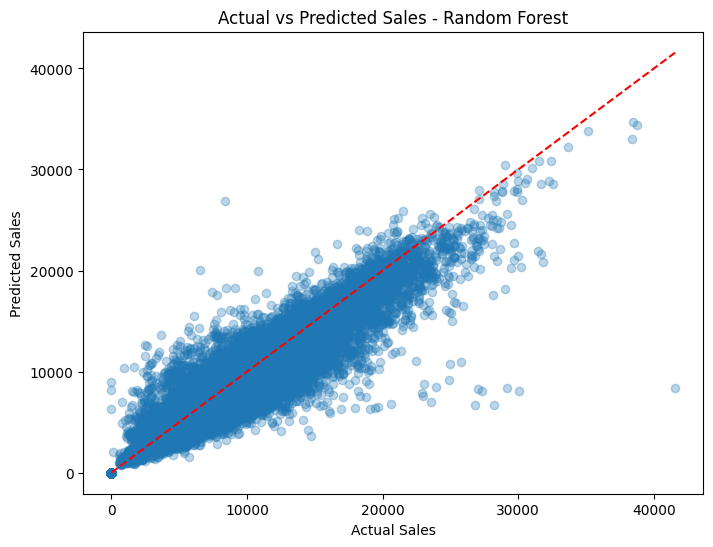

2026-09-12 03:42:20,075 - INFO - Actual vs predicted sales visualization created successfully.


In [38]:
# Plot Actual vs Predicted Sales

plt.figure(figsize=(8, 6))

plt.scatter(
    y_val,
    best_pred,
    alpha=0.3
)

# Reference line: perfect predictions
min_value = min(y_val.min(), best_pred.min())
max_value = max(y_val.max(), best_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title(f"Actual vs Predicted Sales - {best_model_name}")

plt.show()

logger.info("Actual vs predicted sales visualization created successfully.")


# Step 9. Hyperparameter Tuning

## RandomizedSearchCV

The Random Forest model performed best during validation, so we now tune its hyperparameters to try to improve its performance. RandomizedSearchCV tests different combinations of model settings and selects the combination that performs best using cross-validation.

In [39]:
from sklearn.model_selection import RandomizedSearchCV

# Define hyperparameter search space

param_distributions = {
    "model__n_estimators": [50, 100, 150],
    "model__max_depth": [10, 20, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

# Create RandomizedSearchCV

rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Run hyperparameter tuning

rf_random_search.fit(X_train, y_train)

logger.info("Random Forest hyperparameter tuning completed successfully.")


Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
2026-09-12 04:19:21,063 - INFO - Random Forest hyperparameter tuning completed successfully.


Observation

RandomizedSearchCV tested multiple Random Forest hyperparameter combinations and selected the combination with the best cross-validation performance.

## Best Parameters

After the search is completed, we inspect the best hyperparameter combination identified by RandomizedSearchCV.

In [40]:
# Display best hyperparameters

print("Best Hyperparameters:")
print(rf_random_search.best_params_)

print("\nBest Cross-Validation RMSE:")
print(-rf_random_search.best_score_)

Best Hyperparameters:
{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 30}

Best Cross-Validation RMSE:
1124.2452265497477


Observation

RandomizedSearchCV identified the Random Forest hyperparameter combination that achieved the best cross-validation performance within the defined search space. These parameters are used to create the tuned Random Forest model for further evaluation on the chronological validation dataset.

## Evaluate Tuned Model

The best Random Forest model identified through hyperparameter tuning is now evaluated on the same chronological validation dataset. Its performance is compared with the original Random Forest model to determine whether tuning improved the forecasting performance.

In [41]:
# Generate predictions using the tuned Random Forest

tuned_rf_pred = rf_random_search.predict(X_val)

# Calculate evaluation metrics

tuned_rf_mae = mean_absolute_error(y_val, tuned_rf_pred)
tuned_rf_rmse = np.sqrt(mean_squared_error(y_val, tuned_rf_pred))

print("Tuned Random Forest")
print("MAE :", tuned_rf_mae)
print("RMSE:", tuned_rf_rmse)

logger.info("Tuned Random Forest evaluated successfully.")

2026-09-12 04:19:28,601 - INFO - Tuned Random Forest evaluated successfully.


Tuned Random Forest
MAE : 641.403670223412
RMSE: 1042.3502350962333


In [42]:
# Compare original and tuned Random Forest

rf_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        rf_mae,
        tuned_rf_mae
    ],
    "RMSE": [
        rf_rmse,
        tuned_rf_rmse
    ]
})

display(rf_comparison)

logger.info("Original and tuned Random Forest models compared successfully.")

,Model,MAE,RMSE
0,Random Forest,625.164652,1016.366781
1,Tuned Random Forest,641.403670,1042.350235


2026-09-12 04:19:28,640 - INFO - Original and tuned Random Forest models compared successfully.


Observation:

The tuned Random Forest was evaluated on the same chronological validation dataset used for the original Random Forest. The tuning process did not improve validation performance, so the original Random Forest remains the stronger model based on the validation results. The tuned model is therefore not automatically selected simply because it was produced through hyperparameter tuning.

# Step 10. Feature Importance Analysis

In [43]:
# Extract the Random Forest model from the pipeline

rf_model = rf_pipeline.named_steps["model"]

# Get feature names after preprocessing
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance values
feature_importance = rf_model.feature_importances_

# Create feature importance DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

# Sort by importance
importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(importance_df.head(20))


,Feature,Importance
0,num__Open,0.457509
1,num__CompetitionDistance,0.100237
2,num__Store,0.081407
3,num__Promo,0.073139
4,num__WeekOfYear,0.049036
5,num__DayOfWeek,0.037495
6,num__CompetitionOpenSinceYear,0.034787
7,num__CompetitionOpenSinceMonth,0.034500
8,num__CompetitionOpenMonths,0.031208
9,num__Promo2SinceYear,0.020994


Observation

The feature-importance results indicate that store operating status (Open) is the most influential feature for sales prediction. Competition-related information, store identity, promotion activity, and time-based features also contribute substantially to the model's predictions.

Store characteristics such as StoreType and Assortment, along with holiday and promotion-related features, provide additional predictive information.

# Step 11. Prediction Uncertainty

In [44]:
# Get the preprocessing and Random Forest model from the pipeline

preprocessed_val = rf_pipeline.named_steps["preprocessor"].transform(X_val)
rf_model = rf_pipeline.named_steps["model"]

# Generate predictions from individual trees
tree_predictions = np.array([
    tree.predict(preprocessed_val)
    for tree in rf_model.estimators_
])

# Calculate mean prediction
mean_prediction = tree_predictions.mean(axis=0)

# Calculate standard deviation across trees
prediction_std = tree_predictions.std(axis=0)

# Calculate approximate 95% prediction interval
lower_bound = mean_prediction - 1.96 * prediction_std
upper_bound = mean_prediction + 1.96 * prediction_std

# Prevent negative sales predictions
lower_bound = np.maximum(lower_bound, 0)

print("Prediction uncertainty calculated successfully.")

print("\nMean Prediction:")
print(mean_prediction[:10])

print("\nLower Bound:")
print(lower_bound[:10])

print("\nUpper Bound:")
print(upper_bound[:10])

Prediction uncertainty calculated successfully.

Mean Prediction:
[ 8289.763       9583.73027778 10821.11        6982.30916667
  6789.54811905  7401.86866667  7777.39        4355.48
  3977.38        7924.725     ]

Lower Bound:
[5658.49496511 7763.89984348 8574.81704727 6023.5177836  6216.48832204
 6579.38824804 6696.44874208 3471.97963389 3298.61353335 6717.89666067]

Upper Bound:
[10921.03103489 11403.56071207 13067.40295273  7941.10054973
  7362.60791605  8224.34908529  8858.33125792  5238.98036611
  4656.14646665  9131.55333933]


Observation

The prediction uncertainty analysis provides an approximate range around each Random Forest prediction. The variation between individual trees is used to estimate how uncertain the model is for each prediction. Wider intervals indicate greater prediction uncertainty, while narrower intervals indicate more consistent model predictions.

# Step 12. Final Test Prediction

In [45]:
# Generate predictions for the test dataset

test_predictions = rf_pipeline.predict(X_test)

print("Test Predictions Shape:", test_predictions.shape)
print("First 10 Test Predictions:")
print(test_predictions[:10])

logger.info("Test predictions generated successfully.")

2026-09-12 04:20:03,260 - INFO - Test predictions generated successfully.


Test Predictions Shape: (41088,)
First 10 Test Predictions:
[4383.58 9813.92 9395.29 7159.17 6860.44 6162.47 7928.04 7656.99 5105.48
 6035.69]


Observation

The final Random Forest model successfully generated sales predictions for all test records. The prediction output is ready to be combined with the corresponding test IDs for submission.

# Step 13. Model Serialization

Model serialization saves the trained machine learning pipeline so that it can be reused later without retraining the model. The complete pipeline includes both preprocessing and the trained Random Forest model, allowing the same transformations to be applied when making future predictions.

## Save Final ML Pipeline

In [ ]:
import joblib

# Path to save the final Random Forest pipeline
model_path = "../models/final_random_forest_pipeline.pkl"

# Save the final Random Forest pipeline
joblib.dump(
    rf_pipeline,
    model_path
)

logger.info("Final Random Forest pipeline saved successfully.")

print("Pipeline saved successfully:")
print(model_path)

Observation

The final Random Forest pipeline was successfully serialized and saved as a .pkl file. The saved pipeline can be reused for future predictions without retraining the model.

## Load Serialized Pipeline

The saved pipeline is loaded from the serialized file to verify that the trained model can be restored successfully.

In [ ]:
import joblib

model_path = "../models/final_random_forest_pipeline.pkl"

loaded_pipeline = joblib.load(model_path)

print("Pipeline loaded successfully!")

Pipeline loaded successfully!


Observation

The serialized Random Forest pipeline was successfully loaded from the saved .pkl file, confirming that the trained model can be restored for future use.

## Verify Prediction Using Saved Pipeline
The loaded pipeline is used to verify that predictions can be generated using the serialized model. This confirms that the saved pipeline retains both the preprocessing and prediction functionality.

In [31]:
# Verify prediction using the loaded pipeline

sample_prediction = loaded_pipeline.predict(X_test.head(5))

print("Sample Predictions from Loaded Pipeline:")
print(sample_prediction)

logger.info("Prediction using the loaded pipeline verified successfully.")

2026-09-12 05:50:10,308 - INFO - Prediction using the loaded pipeline verified successfully.


Sample Predictions from Loaded Pipeline:
[4383.58 9813.92 9395.29 7159.17 6860.44]


Observation

The loaded pipeline successfully generated predictions for new records, confirming that the serialized model can be reused without retraining.

# Step 14. Logging Summary

Logging was used throughout the machine learning workflow to record important processing, training, evaluation, tuning, prediction, and serialization steps. This provides traceability and helps monitor the execution of the project.

In [32]:
logger.info("Machine learning workflow completed successfully.")
logger.info("Data preparation, feature engineering, model training, evaluation, tuning, prediction, and serialization completed.")

2026-09-12 06:11:45,310 - INFO - Machine learning workflow completed successfully.
2026-09-12 06:11:45,317 - INFO - Data preparation, feature engineering, model training, evaluation, tuning, prediction, and serialization completed.


Observation

The major machine learning workflow steps were recorded through logging, providing a traceable record of the project execution.

# Step 15. Conclusion

The Rossmann sales forecasting model was developed using historical sales data, store characteristics, promotions, holidays, competition information, and time-based features.

Several regression approaches were evaluated, with Random Forest achieving the best validation performance among the initial models. Hyperparameter tuning was also performed, but the tuned model did not improve upon the original Random Forest on the chronological validation dataset. Therefore, the original Random Forest pipeline was retained as the final model.

The final pipeline was serialized and successfully loaded again, confirming that it can be reused for future predictions without retraining.